In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv(r"E:\Data_ Analytics_Project\Zomato_Data_Analysis\Data\zomato.csv")

In [45]:
df.shape

(51717, 17)

In [46]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [47]:
df.head(8)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8/5,286,+91 9980040002\r\n+91 9980063005,Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600,"[('Rated 3.0', 'RATED\n Food 3/5\nAmbience 3/...",[],Buffet,Banashankari
6,https://www.zomato.com/bangalore/rosewood-inte...,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,+91 9731716688\r\n080 26740366,Mysore Road,Casual Dining,NaN,"North Indian, South Indian, Andhra, Chinese",800,"[('Rated 5.0', 'RATED\n Awesome food ??Great ...",[],Buffet,Banashankari
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6/5,2556,080 48653961\r\n080 48655715,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600,"[('Rated 5.0', 'RATED\n I personally really l...",[],Cafes,Banashankari


In [48]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [49]:
# removing /5 from rating 
df['rate'] = df['rate'].str.split('/').str[0]

In [50]:
df['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', 'NEW', '2.9', '3.5', nan,
       '2.6', '3.8 ', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2',
       '2.3', '3.4 ', '-', '3.6 ', '4.8', '3.9 ', '4.2 ', '4.0 ', '4.1 ',
       '3.7 ', '3.1 ', '2.9 ', '3.3 ', '2.8 ', '3.5 ', '2.7 ', '2.5 ',
       '3.2 ', '2.6 ', '4.5 ', '4.3 ', '4.4 ', '4.9', '2.1', '2.0', '1.8',
       '4.6 ', '4.9 ', '3.0 ', '4.8 ', '2.3 ', '4.7 ', '2.4 ', '2.1 ',
       '2.2 ', '2.0 ', '1.8 '], dtype=object)

In [51]:
#replacing "NEW" & "-" with nan 
df['rate'] = df['rate'].replace('NEW',np.nan)

df['rate'] = df['rate'].replace('-',np.nan)


In [52]:
df['rate'].isna().sum()

np.int64(10052)

In [53]:
df['rate'] = df['rate'].astype(float)

In [54]:
df['rate'].dropna()

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51709    3.7
51711    2.5
51712    3.6
51715    4.3
51716    3.4
Name: rate, Length: 41665, dtype: float64

In [55]:
#creating the summary of location based on their restaurant count, average rating & total vote count

location_summary = df.groupby('location').agg(
    restaurant_count=('name','count'),
    avg_rating = ('rate',"mean"),
    total_votes = ('votes',"sum")
)
location_summary

,restaurant_count,avg_rating,total_votes
location,,,
BTM,5124,3.573740,619376
Banashankari,906,3.649866,162374
Banaswadi,664,3.496042,35657
Bannerghatta Road,1630,3.507449,219077
Basavanagudi,684,3.671092,94919
...,...,...,...
West Bangalore,6,3.366667,1110
Whitefield,2144,3.621618,466829
Wilson Garden,246,3.536364,7341


In [56]:
#top location with highest avg-rating
location_summary.sort_values(by = "avg_rating",ascending=False).head(10)

,restaurant_count,avg_rating,total_votes
location,,,
Lavelle Road,529,4.142505,506186
Koramangala 3rd Block,216,4.020419,125159
St. Marks Road,352,4.017201,266099
Koramangala 5th Block,2504,4.005821,2219506
Church Street,569,3.992125,594979
Sankey Road,27,3.965385,6411
Koramangala 4th Block,1017,3.918668,685156
Cunningham Road,491,3.901053,287873
Residency Road,675,3.863636,291954


In [57]:
cuisines_df = df["cuisines"]

In [58]:
type(cuisines_df)

pandas.core.series.Series

In [59]:
cuisines_df.head()

0    North Indian, Mughlai, Chinese
1       Chinese, North Indian, Thai
2            Cafe, Mexican, Italian
3        South Indian, North Indian
4          North Indian, Rajasthani
Name: cuisines, dtype: object

In [60]:
cuisines_df = cuisines_df.dropna()

In [61]:
cuisines_df = cuisines_df.str.split(',')

In [62]:
type(cuisines_df.iloc[0])

list

In [63]:
cuisines_df = cuisines_df.explode()

In [64]:
cuisines_df = cuisines_df.str.strip()

In [65]:
cuisines_df.value_counts().head(10)

cuisines
North Indian    21085
Chinese         15547
South Indian     8644
Fast Food        8096
Biryani          6492
Continental      5765
Desserts         5633
Cafe             5303
Beverages        4747
Italian          3389
Name: count, dtype: int64

In [66]:
#Bangalore restaurant market is budget-heavy or premium-heavy?
df['approx_cost(for two people)'].dtypes

dtype('O')

In [67]:
restaurant_cost_df = df[['name','approx_cost(for two people)']].copy()

In [68]:
restaurant_cost_df['approx_cost(for two people)'] = restaurant_cost_df['approx_cost(for two people)'].str.replace(",","")

In [69]:
restaurant_cost_df['approx_cost(for two people)'].tail()

51712    1500
51713     600
51714    2000
51715    2500
51716    1500
Name: approx_cost(for two people), dtype: object

In [70]:
restaurant_cost_df['approx_cost(for two people)']=pd.to_numeric(
    restaurant_cost_df['approx_cost(for two people)'],
    errors='coerce'
)

In [71]:
restaurant_cost_df['approx_cost(for two people)'].dropna()

0         800.0
1         800.0
2         800.0
3         300.0
4         600.0
          ...  
51712    1500.0
51713     600.0
51714    2000.0
51715    2500.0
51716    1500.0
Name: approx_cost(for two people), Length: 51371, dtype: float64

In [72]:
restaurant_cost_df['approx_cost(for two people)'].max()

np.float64(6000.0)

In [73]:
restaurant_cost_df['approx_cost(for two people)'].describe()

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

In [74]:
cost = [0,500,1000,6000]
segment = ["budget",'mid-range','permium']
restaurant_cost_df['cost_segment'] = pd.cut(restaurant_cost_df['approx_cost(for two people)'],bins=cost,labels=segment)

In [75]:
resturant_type = restaurant_cost_df.groupby('cost_segment').agg(
    NO_of_rest=('approx_cost(for two people)','count')
)
resturant_type

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3552\3661640180.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resturant_type = restaurant_cost_df.groupby('cost_segment').agg(


,NO_of_rest
cost_segment,
budget,33283
mid-range,12808
permium,5280


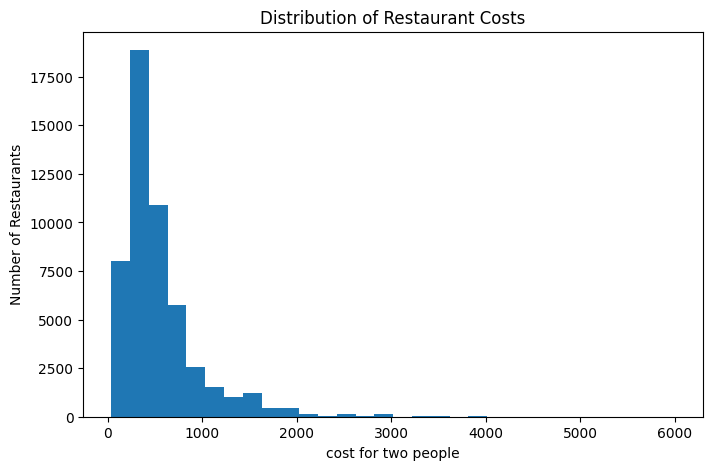

In [76]:
plt.figure(figsize=(8,5))
plt.hist(restaurant_cost_df['approx_cost(for two people)'],bins=30)
plt.xlabel("cost for two people")
plt.ylabel('Number of Restaurants')
plt.title("Distribution of Restaurant Costs")
plt.show()

In [ ]:
# ----------------------------
# Business Insights
# ----------------------------

#1. Most restaurants are concentrated in the lower cost range, indicating strong demand for affordable dining options.

#2. The distribution is right-skewed, with a small number of high-cost restaurants extending the upper tail.

#3. The median cost (₹400) is lower than the average cost (₹555), showing that premium restaurants increase the overall average.

#4. Budget and mid-range restaurants dominate the market, while high-end dining establishments represent a relatively small segment.

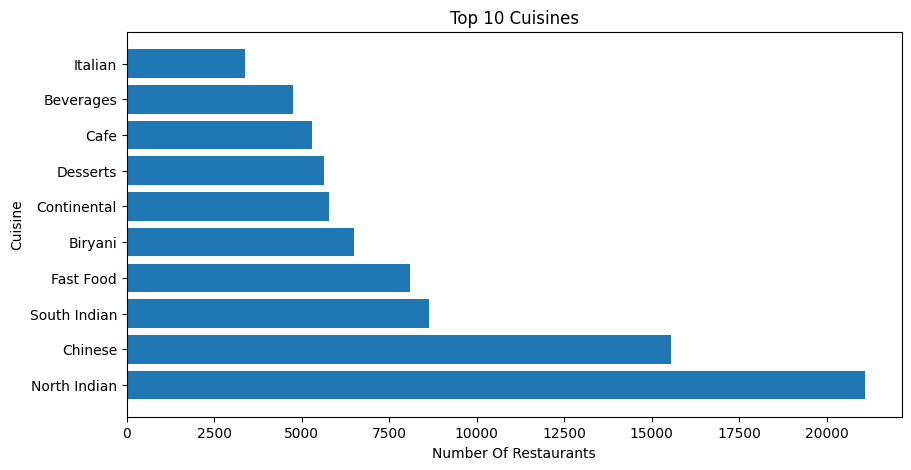

In [77]:
# Cuisine Market Analysis

top_cuisines = cuisines_df.value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_cuisines.index,top_cuisines.values)
plt.title("Top 10 Cuisines")
plt.xlabel("Number Of Restaurants")
plt.ylabel("Cuisine")
plt.show()

In [78]:
# ----------------------------
# Cuisine Market Analysis
# ----------------------------

# Observation:
# North Indian cuisine appears in 21K+ restaurants,
# making it the most common cuisine category.

# Business Insight:
# North Indian and Chinese cuisines dominate the market,
# indicating strong demand but also high competition.

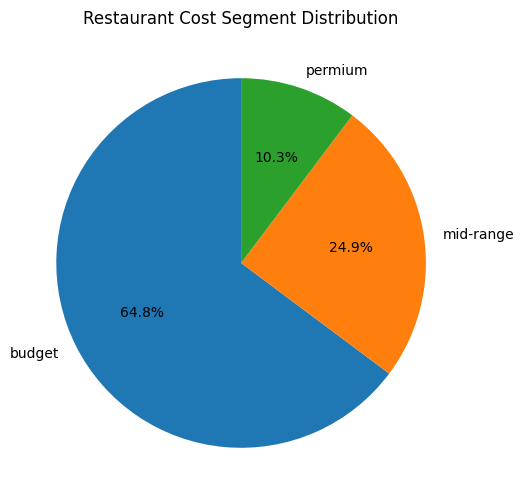

In [79]:
#Cost Segment Distribution

plt.figure(figsize=(6,6))
plt.pie(resturant_type['NO_of_rest'],
       labels = resturant_type.index,
       autopct = '%1.1f%%',
        startangle = 90
)
plt.title("Restaurant Cost Segment Distribution")
plt.show()

In [80]:
# ----------------------------
# Business Insights
# ----------------------------

# 1. Budget restaurants dominate the Bangalore restaurant market,
#    accounting for approximately 65% of all restaurants.

# 2. Mid-range restaurants represent around 25% of the market,
#    indicating significant demand for moderately priced dining options.

# 3. Premium restaurants account for only 10% of total listings,
#    suggesting that high-end dining is a niche segment.

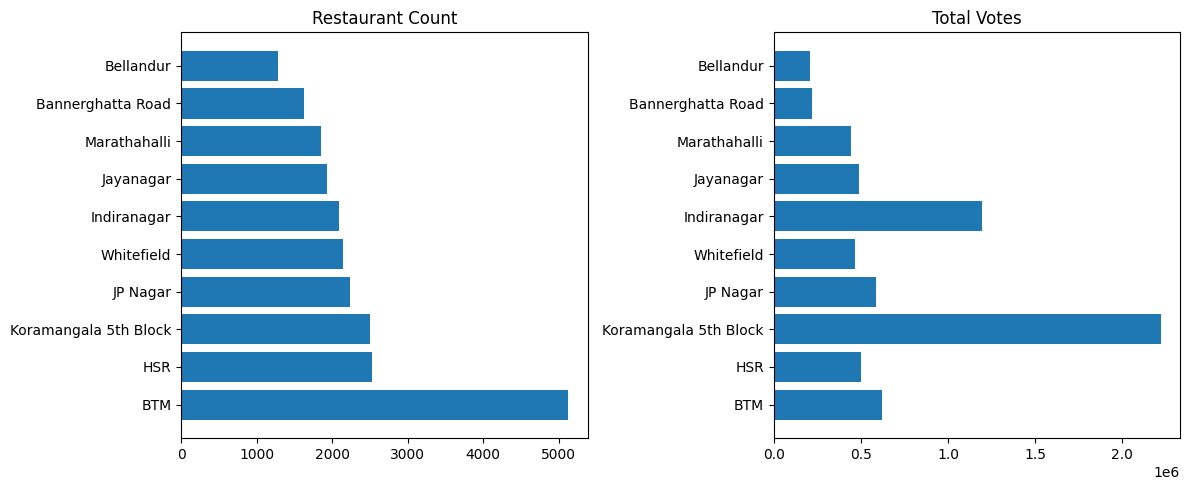

In [85]:
location_summary = location_summary.sort_values(
    'restaurant_count',
    ascending=False
).head(10)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].barh(location_summary.index,
            location_summary['restaurant_count'])

ax[0].set_title("Restaurant Count")

ax[1].barh(location_summary.index,
            location_summary['total_votes'])

ax[1].set_title("Total Votes")
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------
# Business Insights
# ----------------------------

#1. BTM has the highest number of restaurants, 
#making it one of the most competitive food markets in Bangalore.

#2. Koramangala 5th Block receives the highest customer engagement despite having fewer restaurants than BTM.

#3. Indiranagar also shows strong customer engagement, indicating the presence of popular dining destinations.

#4. Restaurant count and customer engagement are not always proportional,
#with Koramangala 5th Block attracting significantly more customer attention than many larger markets.

# Final Conclusions

1. North Indian and Chinese cuisines dominate the Bangalore restaurant market.

2. Budget restaurants account for the majority of market listings, highlighting strong demand for affordable dining.

3. Koramangala 5th Block shows the highest customer engagement, while BTM has the highest restaurant concentration.